# CloudIR Model Comparison and Evaluation

This notebook evaluates the Hugging Face models used by CloudIR's four AI
subsystems -- security reasoning, vision-language evidence reading, AI
coaching feedback, and speech-to-text -- against **persisted benchmark
artifacts** produced by standalone scripts in `notebooks/model_benchmarks/`.

**Ground rule for this notebook:** every number shown below is either read
directly from a CSV/JSON file under `notebooks/model_benchmarks/results/`,
or computed from those files with a calculation visible in the code cell
above it. If a metric was proposed while planning the benchmarks but was
never actually measured, this notebook says so explicitly instead of
estimating or filling in a plausible-looking number. No model inference
runs inside this notebook.

## 0. Evaluation Overview

**Why evaluate.** CloudIR wires one Hugging Face model into each of four
subsystems. Before trusting those choices, each configured (production)
model needs to be compared against plausible alternative candidates on the
same task, using the same cases, so any claim of "this model is a
reasonable choice" is backed by a saved, reproducible result rather than
intuition.

**The four model roles:**

| Role | What it does |
|---|---|
| **Security reasoning** | Classifies how strongly a piece of evidence supports a chosen incident-response action (`Strong / Partial / Weak / Unsupported`). |
| **Vision-language (VLM)** | Reads a generated AWS console screenshot and extracts structured facts plus a support-role judgement. |
| **AI coach** | Produces short feedback text on the analyst's evidence choice, scored against a 7-criterion **Automated Coach Response Rubric Score** (an automated heuristic, not a human-judged quality rating). |
| **Speech-to-text (STT)** | Transcribes spoken analyst notes so their meaning can be checked against the recorded intent. |

**How inference happens.** Model inference is never run inside this
notebook. It is executed ahead of time by standalone scripts --
`security_model_evaluation.py`, `vlm_model_evaluation.py`,
`coach_model_evaluation.py`, `stt_model_evaluation.py` (all under
`notebooks/model_benchmarks/`) -- which write their results to
`notebooks/model_benchmarks/results/`. This notebook only *reads* those
artifacts, computes summary statistics from them, and presents the
result. That separation is what makes every number below reproducible:
re-running the same script with the same arguments regenerates the same
files this notebook reads.

Figure 1 sketches the pipeline from evaluation case to notebook
conclusion.

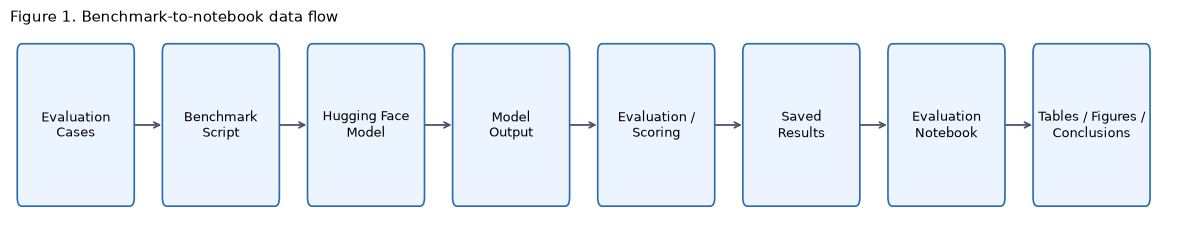

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 2.4))
stages = [
    "Evaluation\nCases", "Benchmark\nScript", "Hugging Face\nModel",
    "Model\nOutput", "Evaluation /\nScoring", "Saved\nResults",
    "Evaluation\nNotebook", "Tables / Figures /\nConclusions",
]
box_w, box_h, gap = 1.25, 0.9, 0.35
x = 0.1
positions = []
for label in stages:
    positions.append(x)
    ax.add_patch(mpatches.FancyBboxPatch((x, 0.1), box_w, box_h,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 linewidth=1.2, edgecolor="#2b6cb0", facecolor="#ebf4ff"))
    ax.text(x + box_w / 2, 0.55, label, ha="center", va="center", fontsize=9)
    x += box_w + gap
for i in range(len(stages) - 1):
    x0 = positions[i] + box_w
    x1 = positions[i + 1]
    ax.annotate("", xy=(x1, 0.55), xytext=(x0, 0.55),
                arrowprops=dict(arrowstyle="->", color="#4a5568", lw=1.3))
ax.set_xlim(0, x); ax.set_ylim(0, 1.1); ax.axis("off")
ax.set_title("Figure 1. Benchmark-to-notebook data flow", fontsize=11, loc="left")
plt.tight_layout(); plt.show()

## 1. Evaluation Architecture

- **`run_benchmarks.py`** is the shared library: it defines the candidate
  model lists (`SECURITY_MODELS`, `VLM_MODELS`, `COACH_MODELS`,
  `STT_MODELS`, each with a `used_in_application` flag), builds the
  evaluation cases from `data/runtime/turns/`, runs inference, and computes
  per-case correctness / scores / latency.
- **`security_model_evaluation.py`, `vlm_model_evaluation.py`,
  `coach_model_evaluation.py`, `stt_model_evaluation.py`** are thin CLI
  wrappers around `run_benchmarks.py` for one model family each. Each
  writes `*_candidates`, `*_cases`, `*_results`, `*_summary` CSV/JSON files
  plus a Markdown report into `notebooks/model_benchmarks/results/`.
- **`evaluation_utils.py`** holds shared helpers (metadata construction,
  candidate-row formatting, Markdown table rendering, artifact
  verification) used by all four scripts.
- **`.env`** records which Hugging Face model ID is actually wired into the
  running CloudIR application for each role (`HF_SECURITY_MODEL_ID`,
  `HF_IMAGE_MODEL_ID`, `HF_COACH_MODEL_ID`, `HF_VOICE_MODEL_ID`). This
  notebook parses `.env` programmatically to resolve which benchmarked
  candidate is the "production" model for each role, rather than assuming
  or hard-coding it per cell.
- **This notebook** loads only the files in `results/` -- it performs no
  model loading, no downloads, and no inference during normal execution.

In [2]:
import os
import json
from pathlib import Path
from typing import Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 100)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "notebooks").exists() and (PROJECT_ROOT.parent / "notebooks").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "notebooks" / "model_benchmarks" / "results"
ENV_PATH = PROJECT_ROOT / ".env"

assert RESULTS_DIR.exists(), f"Results directory not found: {RESULTS_DIR}"
print("Project root:", PROJECT_ROOT)
print("Results dir:", RESULTS_DIR)

Project root: /Users/karunanidhiprabhakar/Desktop/FYP
Results dir: /Users/karunanidhiprabhakar/Desktop/FYP/notebooks/model_benchmarks/results


In [3]:
# ----------------------------------------------------------------------
# Reusable helper functions used throughout the notebook.
# ----------------------------------------------------------------------

def load_csv(name: str) -> pd.DataFrame:
    """Load a results CSV. Returns an empty DataFrame (not an exception) if missing."""
    path = RESULTS_DIR / name
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def load_json(name: str):
    path = RESULTS_DIR / name
    if not path.exists():
        return None
    return json.loads(path.read_text())


def artifact_status(names: list[str]) -> pd.DataFrame:
    rows = []
    for name in names:
        path = RESULTS_DIR / name
        exists = path.exists()
        rows.append({
            "artifact": name,
            "exists": exists,
            "rows": (len(pd.read_csv(path)) if exists and path.suffix == ".csv" else None),
            "size_bytes": path.stat().st_size if exists else 0,
        })
    return pd.DataFrame(rows)


def read_env_model_ids(env_path: Path) -> dict:
    """Parse .env for the four production Hugging Face model IDs. No secrets are read."""
    keys = ["HF_SECURITY_MODEL_ID", "HF_IMAGE_MODEL_ID", "HF_COACH_MODEL_ID", "HF_VOICE_MODEL_ID"]
    result = {k: None for k in keys}
    if not env_path.exists():
        return result
    for line in env_path.read_text(encoding="utf-8").splitlines():
        if "=" not in line or line.strip().startswith("#"):
            continue
        key, _, value = line.partition("=")
        key = key.strip()
        if key in keys:
            result[key] = value.strip()
    return result


def resolve_production_row(summary_df: pd.DataFrame, candidates_df: pd.DataFrame,
                            production_model_id: Optional[str], name_col="model_name"):
    """Resolve the summary row for the model actually used in the application.

    Matching goes through the candidates table's model_id -> name, so the
    production model is identified from .env / used_in_application metadata,
    not assumed or hard-coded.
    """
    if summary_df.empty or candidates_df.empty:
        return None
    prod_candidates = candidates_df[candidates_df.get("used_in_application", False) == True]
    if production_model_id:
        id_match = candidates_df[candidates_df["model_id"] == production_model_id]
        if not id_match.empty:
            prod_candidates = id_match
    if prod_candidates.empty:
        return None
    prod_name = prod_candidates.iloc[0]["name"]
    match = summary_df[summary_df[name_col] == prod_name]
    if match.empty:
        return None
    return match.iloc[0]


def validated_metric(row, column: str) -> str:
    """Data-integrity gate used before any headline number is shown: checks the
    source row exists, the column exists, and the value is numeric/non-null."""
    if row is None or column not in row.index:
        return "Metric unavailable from current benchmark artifacts"
    value = row[column]
    if pd.isna(value):
        return "Metric unavailable from current benchmark artifacts"
    if isinstance(value, (int, float, np.integer, np.floating)):
        return f"{value:.3f}" if isinstance(value, (float, np.floating)) else str(value)
    return str(value)


def figure_note(ax, text: str):
    ax.text(0.0, -0.24, text, transform=ax.transAxes, fontsize=8.5,
             color="#4a5568", va="top", wrap=True)


PRODUCTION_MODEL_IDS = read_env_model_ids(ENV_PATH)
PRODUCTION_MODEL_IDS

{'HF_SECURITY_MODEL_ID': 'fdtn-ai/Foundation-Sec-8B-Instruct',
 'HF_IMAGE_MODEL_ID': 'Qwen/Qwen2.5-VL-3B-Instruct',
 'HF_COACH_MODEL_ID': 'Qwen/Qwen2.5-1.5B-Instruct',
 'HF_VOICE_MODEL_ID': 'openai/whisper-base'}

## 2. Benchmark Dataset and Case Coverage

Table 1 lists the canonical artifact for each task family and the actual
final case/candidate counts used in this notebook. Several near-duplicate
artifact sets exist on disk (a `multitask_*` batch, and an earlier
2-case/8-case security smoke run); those are superseded and are only
referenced in the Appendix for audit purposes. The rows below are what
Sections 5-8 are built from.

In [4]:
CANONICAL_ARTIFACTS = {
    "security": {
        "candidates": "security_model_candidates.csv",
        "cases": "security_evaluation_cases.csv",
        "results": "security_model_focused_results.csv",
        "summary": "security_model_focused_summary.csv",
    },
    "vlm": {
        "candidates": "vlm_model_candidates.csv",
        "cases": "vlm_model_cases.csv",
        "results": "vlm_model_results.csv",
        "summary": "vlm_model_summary.csv",
    },
    "coach": {
        "candidates": "coach_model_candidates.csv",
        "cases": "coach_model_cases.csv",
        "results": "coach_model_results.csv",
        "summary": "coach_model_summary.csv",
    },
    "stt": {
        "candidates": "stt_model_candidates.csv",
        "cases": "stt_model_cases.csv",
        "results": "stt_model_results.csv",
        "summary": "stt_model_summary.csv",
    },
}

all_names = [n for family in CANONICAL_ARTIFACTS.values() for n in family.values()]
status_table = artifact_status(all_names)
status_table.insert(0, "family", sum(([fam] * 4 for fam in CANONICAL_ARTIFACTS), []))
status_table.insert(1, "role", ["candidates", "cases", "results", "summary"] * 4)
status_table = status_table.drop(columns=["artifact"]).rename(columns={"rows": "row_count"})
status_table.insert(2, "filename", all_names)
print("Table 1. Canonical benchmark artifact status (per model family)")
status_table

Table 1. Canonical benchmark artifact status (per model family)


,family,role,filename,exists,row_count,size_bytes
0,security,candidates,security_model_candidates.csv,True,10,3241
1,security,cases,security_evaluation_cases.csv,True,20,2491
2,security,results,security_model_focused_results.csv,True,120,17261
3,security,summary,security_model_focused_summary.csv,True,6,354
4,vlm,candidates,vlm_model_candidates.csv,True,4,1119
5,vlm,cases,vlm_model_cases.csv,True,5,1123
6,vlm,results,vlm_model_results.csv,True,20,14892
7,vlm,summary,vlm_model_summary.csv,True,4,256
8,coach,candidates,coach_model_candidates.csv,True,4,722
9,coach,cases,coach_model_cases.csv,True,16,1297


In [5]:
sec_cand = load_csv(CANONICAL_ARTIFACTS["security"]["candidates"])
sec_cases = load_csv(CANONICAL_ARTIFACTS["security"]["cases"])
sec_results = load_csv(CANONICAL_ARTIFACTS["security"]["results"])
sec_summary = load_csv(CANONICAL_ARTIFACTS["security"]["summary"])

vlm_cand = load_csv(CANONICAL_ARTIFACTS["vlm"]["candidates"])
vlm_results = load_csv(CANONICAL_ARTIFACTS["vlm"]["results"])
vlm_summary = load_csv(CANONICAL_ARTIFACTS["vlm"]["summary"])

coach_cand = load_csv(CANONICAL_ARTIFACTS["coach"]["candidates"])
coach_cases = load_csv(CANONICAL_ARTIFACTS["coach"]["cases"])
coach_results = load_csv(CANONICAL_ARTIFACTS["coach"]["results"])
coach_summary = load_csv(CANONICAL_ARTIFACTS["coach"]["summary"])

stt_cand = load_csv(CANONICAL_ARTIFACTS["stt"]["candidates"])
stt_results = load_csv(CANONICAL_ARTIFACTS["stt"]["results"])
stt_summary = load_csv(CANONICAL_ARTIFACTS["stt"]["summary"])

coverage_table = pd.DataFrame([
    {"Task": "Security reasoning", "Production Model": "Foundation-Sec-8B-Instruct",
     "Cases": sec_results["case_id"].nunique(),
     "Candidates": sec_summary["model_name"].nunique(),
     "Main Evaluation Dimensions": "support-verdict accuracy, latency, evidence-strength breakdown"},
    {"Task": "VLM (evidence reading)", "Production Model": "Qwen2.5-VL-3B-Instruct",
     "Cases": vlm_results["case_id"].nunique(),
     "Candidates": vlm_summary["model_name"].nunique(),
     "Main Evaluation Dimensions": "support-role parse accuracy, keyword recall, latency"},
    {"Task": "AI coach feedback", "Production Model": "Qwen2.5-1.5B-Instruct",
     "Cases": coach_results["case_id"].nunique(),
     "Candidates": coach_summary["model_name"].nunique(),
     "Main Evaluation Dimensions": "Automated Coach Response Rubric Score (0-7), per-criterion pass rate, latency"},
    {"Task": "Speech-to-text", "Production Model": "whisper-base",
     "Cases": stt_results["sample_id"].nunique(),
     "Candidates": stt_summary["model_name"].nunique(),
     "Main Evaluation Dimensions": "word error rate (WER), keyword recall, meaning preservation, latency"},
])
print("Table 2. Benchmark dataset and case coverage (actual final counts)")
coverage_table

Table 2. Benchmark dataset and case coverage (actual final counts)


,Task,Production Model,Cases,Candidates,Main Evaluation Dimensions
0,Security reasoning,Foundation-Sec-8B-Instruct,20,6,"support-verdict accuracy, latency, evidence-strength breakdown"
1,VLM (evidence reading),Qwen2.5-VL-3B-Instruct,5,4,"support-role parse accuracy, keyword recall, latency"
2,AI coach feedback,Qwen2.5-1.5B-Instruct,16,4,"Automated Coach Response Rubric Score (0-7), per-criterion pass rate, latency"
3,Speech-to-text,whisper-base,8,4,"word error rate (WER), keyword recall, meaning preservation, latency"


## 3. Metric Definitions and Provenance

Table 3 lists every metric used anywhere in this notebook, where it comes
from, and how it is calculated. `AVAILABLE` means the column exists in a
saved artifact and is used as-is; `DERIVABLE` means it is computed in a
notebook cell from available columns; `NOT_MEASURED` means it was
discussed while planning the benchmarks but is not present in any saved
artifact -- those are never estimated or substituted.

In [6]:
metric_provenance = pd.DataFrame([
    {"Metric": "support-verdict accuracy", "Task": "Security", "Source Artifact": "security_model_focused_results.csv",
     "Calculation": "mean(correct) where correct = (predicted_verdict == expected_verdict)", "Status": "AVAILABLE"},
    {"Metric": "latency_seconds (per case)", "Task": "Security / Coach / STT", "Source Artifact": "*_results.csv",
     "Calculation": "wall-clock seconds for a single model.generate() call, recorded by run_benchmarks.py", "Status": "AVAILABLE"},
    {"Metric": "support_role_accuracy", "Task": "VLM", "Source Artifact": "vlm_model_results.csv",
     "Calculation": "mean(support_role_correct) where predicted_support_role is parsed from output_text via extract_support_role()", "Status": "AVAILABLE"},
    {"Metric": "keyword_recall", "Task": "VLM / STT", "Source Artifact": "vlm_model_results.csv / stt_model_results.csv",
     "Calculation": "len(matched_keywords) / len(expected_keywords), substring match against output_text/transcript", "Status": "AVAILABLE"},
    {"Metric": "Automated Coach Response Rubric Score", "Task": "Coach", "Source Artifact": "coach_model_results.csv",
     "Calculation": "sum of 7 boolean criteria in coach_rubric_breakdown() (Section 7.2); 0-7 scale", "Status": "AVAILABLE"},
    {"Metric": "criterion_*_pass_rate", "Task": "Coach", "Source Artifact": "coach_model_summary.csv",
     "Calculation": "mean of each individual boolean criterion column across cases, per candidate", "Status": "AVAILABLE"},
    {"Metric": "word_error_rate (WER)", "Task": "STT", "Source Artifact": "stt_model_results.csv",
     "Calculation": "word_error_rate() in run_benchmarks.py: Levenshtein word-alignment edit distance (S+D+I)/N_reference_words", "Status": "AVAILABLE"},
    {"Metric": "meaning_preserved", "Task": "STT", "Source Artifact": "stt_model_results.csv",
     "Calculation": "boolean heuristic combining keyword_recall against a threshold (see stt_model_evaluation_metadata.json)", "Status": "AVAILABLE"},
    {"Metric": "model loading time", "Task": "all", "Source Artifact": "none", "Calculation": "not separately timed from inference latency", "Status": "NOT_MEASURED"},
    {"Metric": "memory / VRAM usage", "Task": "all", "Source Artifact": "none", "Calculation": "no torch.cuda.max_memory_allocated() / resource instrumentation was added", "Status": "NOT_MEASURED"},
    {"Metric": "human-judged coach quality", "Task": "Coach", "Source Artifact": "none",
     "Calculation": "coach_score() is an automated proxy only -- no human ratings were collected", "Status": "NOT_MEASURED"},
    {"Metric": "independent per-case VLM security context", "Task": "Security", "Source Artifact": "none",
     "Calculation": "security cases use case-construction-derived visible facts, not a live VLM inference per case (Section 5.1/5.6)", "Status": "NOT_MEASURED"},
])
print("Table 3. Metric provenance -- every metric used later must appear here")
metric_provenance

Table 3. Metric provenance -- every metric used later must appear here


,Metric,Task,Source Artifact,Calculation,Status
0,support-verdict accuracy,Security,security_model_focused_results.csv,mean(correct) where correct = (predicted_verdict == expected_verdict),AVAILABLE
1,latency_seconds (per case),Security / Coach / STT,*_results.csv,"wall-clock seconds for a single model.generate() call, recorded by run_benchmarks.py",AVAILABLE
2,support_role_accuracy,VLM,vlm_model_results.csv,mean(support_role_correct) where predicted_support_role is parsed from output_text via extract_s...,AVAILABLE
3,keyword_recall,VLM / STT,vlm_model_results.csv / stt_model_results.csv,"len(matched_keywords) / len(expected_keywords), substring match against output_text/transcript",AVAILABLE
4,Automated Coach Response Rubric Score,Coach,coach_model_results.csv,sum of 7 boolean criteria in coach_rubric_breakdown() (Section 7.2); 0-7 scale,AVAILABLE
5,criterion_*_pass_rate,Coach,coach_model_summary.csv,"mean of each individual boolean criterion column across cases, per candidate",AVAILABLE
6,word_error_rate (WER),STT,stt_model_results.csv,word_error_rate() in run_benchmarks.py: Levenshtein word-alignment edit distance (S+D+I)/N_refer...,AVAILABLE
7,meaning_preserved,STT,stt_model_results.csv,boolean heuristic combining keyword_recall against a threshold (see stt_model_evaluation_metadat...,AVAILABLE
8,model loading time,all,none,not separately timed from inference latency,NOT_MEASURED
9,memory / VRAM usage,all,none,no torch.cuda.max_memory_allocated() / resource instrumentation was added,NOT_MEASURED


## 4. Production Model Summary

Table 4 gives one card per task: the model actually configured in `.env`
(resolved programmatically, not hard-coded), how many cases it was
benchmarked on, its primary quality metric, its technical (latency)
metric, and its most notable observed weakness. This replaces a single
shared-axis executive-summary chart -- Security accuracy, VLM keyword
recall, the 0-7 Coach rubric, and STT WER are not comparable numbers and
are deliberately never plotted on one axis (see Section 9 for the
latency-only cross-task comparison, which *is* a comparable unit).

In [7]:
def production_row(task):
    summary = {"security": sec_summary, "vlm": vlm_summary, "coach": coach_summary, "stt": stt_summary}[task]
    cand = {"security": sec_cand, "vlm": vlm_cand, "coach": coach_cand, "stt": stt_cand}[task]
    env_key = {"security": "HF_SECURITY_MODEL_ID", "vlm": "HF_IMAGE_MODEL_ID",
               "coach": "HF_COACH_MODEL_ID", "stt": "HF_VOICE_MODEL_ID"}[task]
    return resolve_production_row(summary, cand, PRODUCTION_MODEL_IDS.get(env_key))

sec_prod = production_row("security")
vlm_prod = production_row("vlm")
coach_prod = production_row("coach")
stt_prod = production_row("stt")

cards = pd.DataFrame([
    {"Task": "Security reasoning", "Model ID": PRODUCTION_MODEL_IDS["HF_SECURITY_MODEL_ID"],
     "N cases": validated_metric(sec_prod, "cases"),
     "Primary metric": f"accuracy = {validated_metric(sec_prod, 'accuracy')}",
     "Latency (s/case)": validated_metric(sec_prod, "avg_latency_seconds"),
     "Observed weakness": "See Section 5.6 -- ground-truth-context methodology caveat applies to this whole task."},
    {"Task": "VLM evidence reading", "Model ID": PRODUCTION_MODEL_IDS["HF_IMAGE_MODEL_ID"],
     "N cases": validated_metric(vlm_prod, "cases"),
     "Primary metric": f"support_role_accuracy = {validated_metric(vlm_prod, 'support_role_accuracy')}",
     "Latency (s/case)": validated_metric(vlm_prod, "avg_latency_seconds"),
     "Observed weakness": "Not the highest keyword-recall candidate (florence-2-base-ft scores higher); see Section 6.2/6.4."},
    {"Task": "AI coach feedback", "Model ID": PRODUCTION_MODEL_IDS["HF_COACH_MODEL_ID"],
     "N cases": validated_metric(coach_prod, "cases"),
     "Primary metric": f"avg_automated_rubric_score = {validated_metric(coach_prod, 'avg_automated_rubric_score')} / 7",
     "Latency (s/case)": validated_metric(coach_prod, "avg_latency_seconds"),
     "Observed weakness": "See Section 7.7 for the lowest-scoring cases."},
    {"Task": "Speech-to-text", "Model ID": PRODUCTION_MODEL_IDS["HF_VOICE_MODEL_ID"],
     "N cases": validated_metric(stt_prod, "samples"),
     "Primary metric": f"mean_wer = {validated_metric(stt_prod, 'mean_wer')}",
     "Latency (s/case)": validated_metric(stt_prod, "avg_latency_seconds"),
     "Observed weakness": "Weakest WER/recall of the four Whisper candidates on this set (Section 8.4)."},
])
print("Table 4. Production model summary (resolved from .env, not hard-coded)")
cards

Table 4. Production model summary (resolved from .env, not hard-coded)


,Task,Model ID,N cases,Primary metric,Latency (s/case),Observed weakness
0,Security reasoning,fdtn-ai/Foundation-Sec-8B-Instruct,20,accuracy = 0.750,49.346,See Section 5.6 -- ground-truth-context methodology caveat applies to this whole task.
1,VLM evidence reading,Qwen/Qwen2.5-VL-3B-Instruct,5,support_role_accuracy = 0.400,127.972,Not the highest keyword-recall candidate (florence-2-base-ft scores higher); see Section 6.2/6.4.
2,AI coach feedback,Qwen/Qwen2.5-1.5B-Instruct,16,avg_automated_rubric_score = 5.250 / 7,3.451,See Section 7.7 for the lowest-scoring cases.
3,Speech-to-text,openai/whisper-base,8,mean_wer = 1.502,1.131,Weakest WER/recall of the four Whisper candidates on this set (Section 8.4).


## 5. Security Reasoning Evaluation

**Purpose.** Classify how strongly a piece of evidence supports a chosen
incident-response action, returning one of `Strong Support / Partial
Support / Weak Support / Unsupported`.

### 5.1 Evaluation Design

The 20 security cases are built from the actual CloudIR turn data
(`data/runtime/turns/`), one per evidence item across 4 turns, covering
all 4 expected support levels evenly and 7 underlying evidence types.

In [8]:
print("Table 5. Security evaluation case coverage")
sec_case_role_counts = sec_cases["expected_support_role"].value_counts().rename_axis("expected_support_role").reset_index(name="n_cases")
sec_case_type_counts = sec_cases["evidence_type"].value_counts().rename_axis("evidence_type").reset_index(name="n_cases")
display(sec_case_role_counts)
display(sec_case_type_counts)

Table 5. Security evaluation case coverage


,expected_support_role,n_cases
0,strong,5
1,partial,5
2,weak,5
3,unsupported,5


,evidence_type,n_cases
0,unknown,5
1,cloudtrail,4
2,cloudwatch,3
3,access_key,3
4,billing,3
5,guardduty,1
6,iam_activity,1


### 5.2 Candidate Comparison

Figure 2 compares support-verdict accuracy and average per-case latency
across all 6 benchmarked candidates on the same 20 cases.

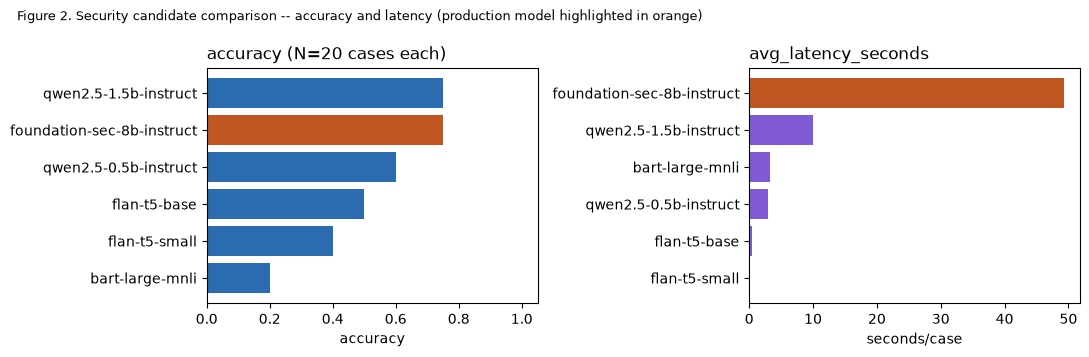

,model_name,cases,accuracy,avg_latency_seconds,total_latency_seconds,unparseable,errors
3,foundation-sec-8b-instruct,20,0.75,49.346,986.910,0,0
5,qwen2.5-1.5b-instruct,20,0.75,9.998,199.968,0,0
4,qwen2.5-0.5b-instruct,20,0.60,2.895,57.898,0,0
1,flan-t5-base,20,0.50,0.413,8.255,0,0
2,flan-t5-small,20,0.40,0.103,2.064,0,0
0,bart-large-mnli,20,0.20,3.254,65.074,0,0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
order = sec_summary.sort_values("accuracy")
colors = ["#c05621" if n == "foundation-sec-8b-instruct" else "#2b6cb0" for n in order["model_name"]]
axes[0].barh(order["model_name"], order["accuracy"], color=colors)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel("accuracy")
axes[0].set_title("accuracy (N=20 cases each)", loc="left")

order2 = sec_summary.sort_values("avg_latency_seconds")
colors2 = ["#c05621" if n == "foundation-sec-8b-instruct" else "#805ad5" for n in order2["model_name"]]
axes[1].barh(order2["model_name"], order2["avg_latency_seconds"], color=colors2)
axes[1].set_xlabel("seconds/case")
axes[1].set_title("avg_latency_seconds", loc="left")

fig.suptitle("Figure 2. Security candidate comparison -- accuracy and latency (production model highlighted in orange)", fontsize=9.5, x=0.02, ha="left")
plt.tight_layout(); plt.show()
sec_summary.sort_values("accuracy", ascending=False)

**Interpretation.** On the leak-free rerun, `foundation-sec-8b-instruct`
(production) and `qwen2.5-1.5b-instruct` are **tied for the best accuracy**
of the 6 candidates at `accuracy = 0.75` (15/20 correct each), followed by
`qwen2.5-0.5b-instruct` (0.6), `flan-t5-base` (0.5), `flan-t5-small` (0.4),
and `bart-large-mnli` (0.2, the weakest candidate). The production model's
conclusion **still holds leak-free**: it remains competitive with -- tied
for -- the best-performing candidate, even after the three ground-truth
leaks described in Section 5.6 were removed and the benchmark rerun from
scratch. It is also the slowest candidate by a wide margin (~49s/case vs
0.1-10s/case for the others) -- see Section 5.5.

In [10]:
print("Production security model card")
print("Model ID (.env HF_SECURITY_MODEL_ID):", PRODUCTION_MODEL_IDS["HF_SECURITY_MODEL_ID"])
sec_prod

Production security model card
Model ID (.env HF_SECURITY_MODEL_ID): fdtn-ai/Foundation-Sec-8B-Instruct


model_name               foundation-sec-8b-instruct
cases                                            20
accuracy                                       0.75
avg_latency_seconds                          49.346
total_latency_seconds                        986.91
unparseable                                       0
errors                                            0
Name: 3, dtype: object

### 5.4 Evidence-Strength Analysis

Table 6 breaks per-case correctness down by `expected_support_role`, for
each candidate, as a heatmap-style pivot table (1.0 = all cases in that
support-role bucket answered correctly).

In [11]:
pivot = sec_results.pivot_table(index="model_name", columns="expected_support_role", values="correct", aggfunc="mean").round(3)
print("Table 6. Accuracy by expected support role (1.0 = fully correct on that bucket)")
styled = pivot.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
styled

Table 6. Accuracy by expected support role (1.0 = fully correct on that bucket)


expected_support_role,partial,strong,unsupported,weak
model_name,,,,
bart-large-mnli,0.000000,0.800000,0.000000,0.000000
flan-t5-base,0.000000,1.000000,1.000000,0.000000
flan-t5-small,0.000000,0.200000,1.000000,0.400000
foundation-sec-8b-instruct,0.800000,0.600000,1.000000,0.600000
qwen2.5-0.5b-instruct,1.000000,0.600000,0.000000,0.800000
qwen2.5-1.5b-instruct,0.400000,0.800000,1.000000,0.800000


### 5.5 Technical Performance

Table 7 shows descriptive latency statistics (mean/median/min/max, with
N) computed directly from the per-case `latency_seconds` column.

In [12]:
lat_stats = sec_results.groupby("model_name")["latency_seconds"].agg(
    N="count", mean="mean", median="median", min="min", max="max"
).round(3).sort_values("mean")
print("Table 7. Security latency_seconds descriptive statistics, per candidate")
lat_stats

Table 7. Security latency_seconds descriptive statistics, per candidate


,N,mean,median,min,max
model_name,,,,,
flan-t5-small,20,0.103,0.094,0.052,0.407
flan-t5-base,20,0.413,0.311,0.177,2.672
qwen2.5-0.5b-instruct,20,2.895,3.026,1.919,4.216
bart-large-mnli,20,3.254,3.346,2.088,6.262
qwen2.5-1.5b-instruct,20,9.998,10.729,6.732,14.395
foundation-sec-8b-instruct,20,49.346,50.408,33.742,89.331


### 5.6 Failure Analysis and Methodology Caveat

**Failure analysis.** On the leak-free rerun, misses scale roughly
inversely with model capability: `bart-large-mnli` misses the most (16 of
20, accuracy 0.2), followed by `flan-t5-small` (12 of 20, 0.4),
`flan-t5-base` (10 of 20, 0.5), `qwen2.5-0.5b-instruct` (8 of 20, 0.6),
and the two joint-best candidates `foundation-sec-8b-instruct` (production)
and `qwen2.5-1.5b-instruct` each miss 5 of 20 (accuracy 0.75). Table 8
lists every missed case across all 6 candidates, drawn straight from the
per-case `correct` column.

In [13]:
print("Table 8. Misclassified security cases (candidates with accuracy < 1.0)")
missed = sec_results[sec_results["correct"] == False][["model_name", "case_id", "expected_verdict", "predicted_verdict", "latency_seconds"]]
missed.sort_values(["model_name", "case_id"])

Table 8. Misclassified security cases (candidates with accuracy < 1.0)


,model_name,case_id,expected_verdict,predicted_verdict,latency_seconds
101,bart-large-mnli,turn_1_access_key_status,Partial Support,Strong Support,3.444
102,bart-large-mnli,turn_1_cloudtrail_event,Weak Support,Strong Support,3.342
103,bart-large-mnli,turn_1_unsupported_unrelated,Unsupported,Partial Support,2.209
104,bart-large-mnli,turn_2_access_key_status_check,Partial Support,Strong Support,3.350
105,bart-large-mnli,turn_2_cloudtrail_event_1,Strong Support,Partial Support,3.050
106,bart-large-mnli,turn_2_cloudwatch_log_insight_query_result,Weak Support,Strong Support,3.690
107,bart-large-mnli,turn_2_unsupported_unrelated,Unsupported,Partial Support,2.215
109,bart-large-mnli,turn_3_billing_impact_snapshot,Weak Support,Strong Support,2.983
108,bart-large-mnli,turn_3_cloudtrail_logging_recovery_check,Partial Support,Strong Support,3.593
111,bart-large-mnli,turn_3_unsupported_unrelated,Unsupported,Partial Support,2.318


**Evaluation-validity correction (methodology caveat -- read this before
trusting the numbers above).** During evaluation validation, three prompt
fields were found to reproduce the case's own ground-truth label rather
than runtime-observable information, before the notebook was finalised:

| Field | Previously contained | Now contains / removed | Why it mattered |
|---|---|---|---|
| `vlm_output["security_relevance"]` | The case's ground-truth `support_role` (e.g. `"strong"`) | `"unknown"` | Directly stated the answer inside the "visible facts" block of the prompt. |
| `vlm_output["supports_selected_action"]` | Same ground-truth `support_role` value | `"unknown"` | Same leak, under a second field name. |
| `selected_evidence["supportRole"]` (serialized into the prompt's evidence JSON) | The case's ground-truth `support_role` | Removed from the prompt-facing copy of `selected_evidence` (still retained internally for scoring) | A third, independent copy of the same leaked label. |
| `learner_justification.transcript` | Plain-English sentence stating *"This evidence should provide `{support_role}` support because..."* | Reworded to describe only the action/evidence selection, without asserting a support level | Leaked the answer in natural language, not just structured fields. |

These fields were removed from `vlm_output_from_evidence()`,
`to_selected_evidence()`/`build_security_prompt()`, and
`build_justification()` in `run_benchmarks.py`, and the security benchmark
was **rerun from scratch** on the same 20 cases and the same 6 candidates.
**The results shown in Sections 5.1-5.5 above are from the leak-free
rerun** (`security-full-20case-run-leakfree`); the earlier, leaky run
(`security-full-20case-run-bf16-fix`) is preserved read-only under
`notebooks/model_benchmarks/results/superseded/LEAKY_security-full-20case-run-bf16-fix/`
for provenance and is never used for any number in this notebook.

This is reported as an **evaluation-validity correction**, not an accuracy
optimisation: the fix was made to the case-construction/prompt code before
seeing whether it helped or hurt any candidate's score, and applies
identically to all 6 candidates. See the Appendix for the exact
before/after prompt text.

**Residual limitation.** The `visible_facts_extracted` /
`important_visible_fields` values fed into the security prompt are still
derived directly from each evidence item's structured `facts` field in
`data/runtime/turns/`, not from an independently-run VLM pass over the
evidence screenshot for each case (except where a genuinely VLM-generated
`saved_vlm` trace was available as a fallback -- see
`vlm_output_from_evidence()`'s `saved_vlm.get(...)` fallback, which is only
exercised when the case's own structured facts are empty; in this case set
every evidence item has non-empty structured facts, so the fallback path
is not exercised and all 20 cases use the structured-facts path). This
means the security benchmark still measures the model's ability to reason
from **accurate, evidence-derived factual content** to a support
classification, rather than from a raw, error-prone VLM read of the
screenshot end-to-end. That is a narrower, more controlled test than
"can this model do the whole CloudIR incident-response pipeline
end-to-end" -- it isolates the security-reasoning step specifically. This
is stated as a scope limitation, not a flaw to fix by re-scoring.

## 6. VLM Evaluation

**Purpose.** Read a generated AWS console evidence screenshot and extract
structured facts plus a support-role judgement.

### 6.1 Limited Evaluation Design

This task is deliberately kept smaller than Security/Coach/STT: 4
candidates x 5 cases (20 image/candidate pairs total), versus 20 Security
cases and 16 Coach cases. VLM inference on this CPU-only development
machine is far slower than the text-only tasks (see Table 9/latency
figures below -- ~97-128s/case for the two Qwen candidates), so the case
count was expanded moderately (from an earlier N=1 pass) rather than to a
size comparable with the other three tasks. This is an explicit,
acknowledged constraint, not a hidden limitation -- see Section 6.5.


In [14]:
print("Table 9. VLM candidate models")
display_cols = [c for c in ["selected_for_run", "used_in_application", "name", "model_id", "family"] if c in vlm_cand.columns]
vlm_cand[display_cols]

Table 9. VLM candidate models


,selected_for_run,used_in_application,name,model_id,family
0,True,True,qwen2.5-vl-3b-instruct,Qwen/Qwen2.5-VL-3B-Instruct,vision-language instruction model
1,True,False,qwen2-vl-2b-instruct,Qwen/Qwen2-VL-2B-Instruct,smaller vision-language instruction model
2,True,False,llava-onevision-0.5b,llava-hf/llava-onevision-qwen2-0.5b-ov-hf,small open VLM baseline
3,True,False,florence-2-base-ft,microsoft/Florence-2-base-ft,compact OCR/captioning vision-language model


### 6.2 Existing Candidate Results

Figure 3 compares `support_role_accuracy` and `avg_keyword_recall` across
the 4 candidates on the single benchmarked case.

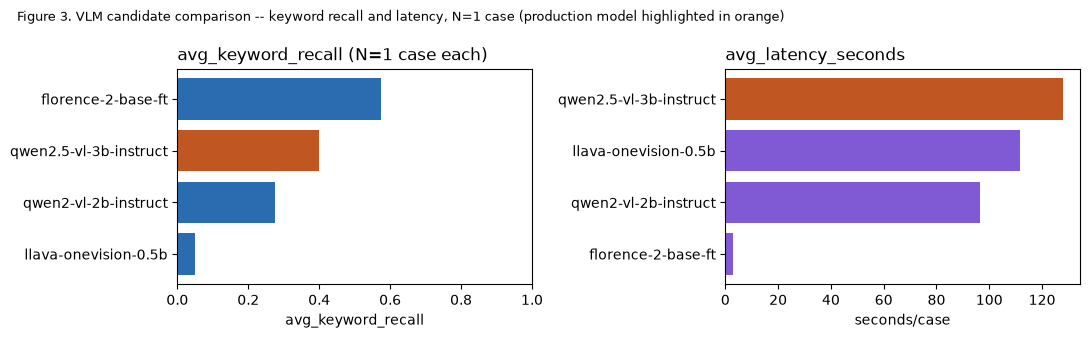

,model_name,cases,support_role_accuracy,avg_keyword_recall,avg_latency_seconds,errors
0,florence-2-base-ft,5,0.0,0.575,2.879,0
3,qwen2.5-vl-3b-instruct,5,0.4,0.400,127.972,0
2,qwen2-vl-2b-instruct,5,0.4,0.275,96.589,0
1,llava-onevision-0.5b,5,0.0,0.050,111.741,0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
order = vlm_summary.sort_values("avg_keyword_recall")
colors = ["#c05621" if n == "qwen2.5-vl-3b-instruct" else "#2b6cb0" for n in order["model_name"]]
axes[0].barh(order["model_name"], order["avg_keyword_recall"], color=colors)
axes[0].set_xlim(0, 1.0)
axes[0].set_xlabel("avg_keyword_recall")
axes[0].set_title("avg_keyword_recall (N=1 case each)", loc="left")

order2 = vlm_summary.sort_values("avg_latency_seconds")
colors2 = ["#c05621" if n == "qwen2.5-vl-3b-instruct" else "#805ad5" for n in order2["model_name"]]
axes[1].barh(order2["model_name"], order2["avg_latency_seconds"], color=colors2)
axes[1].set_xlabel("seconds/case")
axes[1].set_title("avg_latency_seconds", loc="left")

fig.suptitle("Figure 3. VLM candidate comparison -- keyword recall and latency, N=1 case (production model highlighted in orange)", fontsize=9.5, x=0.02, ha="left")
plt.tight_layout(); plt.show()
vlm_summary.sort_values("avg_keyword_recall", ascending=False)

**Interpretation.** Across the 5 cases, `florence-2-base-ft` still reaches
the **highest** `avg_keyword_recall` (0.575), ahead of the production
model `qwen2.5-vl-3b-instruct` (0.400); `qwen2-vl-2b-instruct` reaches
0.275 and `llava-onevision-0.5b` reaches 0.05. **The production model is
therefore not the highest-recall candidate on this data**, and this
notebook does not claim otherwise.

`support_role_accuracy` now parses and scores meaningfully for the two
Qwen candidates (production `qwen2.5-vl-3b-instruct` = 0.4, tied with
`qwen2-vl-2b-instruct` = 0.4) after the token-truncation bug described in
Section 6.4 was fixed and the benchmark rerun. `llava-onevision-0.5b` and
`florence-2-base-ft` still show `support_role_accuracy = 0.0`, but for two
different and genuine reasons -- see Section 6.4.

### 6.3 Production Model Result


In [16]:
print("Production VLM model card")
print("Model ID (.env HF_IMAGE_MODEL_ID):", PRODUCTION_MODEL_IDS["HF_IMAGE_MODEL_ID"])
vlm_prod

Production VLM model card
Model ID (.env HF_IMAGE_MODEL_ID): Qwen/Qwen2.5-VL-3B-Instruct


model_name               qwen2.5-vl-3b-instruct
cases                                         5
support_role_accuracy                       0.4
avg_keyword_recall                          0.4
avg_latency_seconds                     127.972
errors                                        0
Name: 3, dtype: object

### 6.4 Parsing / Failure Analysis

An earlier pass of this benchmark (`max_new_tokens=48`) produced
`predicted_support_role = "unparseable"` for every candidate on every
case. Two rounds of debugging during this evaluation pass found three
distinct, genuine causes -- one generation-configuration bug, one
inference-backend bug, and one architectural mismatch that is not a bug
at all. Table 10 shows one representative raw output per candidate from
the current (fixed) run.


In [17]:
print("Table 10. VLM raw output_text per candidate (first case: turn_1_cloudwatch_insights_query)")
first_case_id = vlm_results["case_id"].iloc[0]
for _, row in vlm_results[vlm_results["case_id"] == first_case_id].iterrows():
    print(f"--- {row['model_name']} (predicted_support_role={row['predicted_support_role']}, support_role_correct={row['support_role_correct']}, output length={len(str(row['output_text']))} chars) ---")
    print(str(row["output_text"])[:600])
    print()


Table 10. VLM raw output_text per candidate (first case: turn_1_cloudwatch_insights_query)
--- qwen2.5-vl-3b-instruct (predicted_support_role=strong, support_role_correct=True, output length=527 chars) ---
```json
{
  "evidence_type": "cloudwatch",
  "supports_selected_action": "strong",
  "visible_facts": {
    "timestamp": [
      "2023-01-01T12:00:02Z",
      "2023-01-01T11:59:52Z",
      "2023-01-01T10:21:35Z",
      "2023-01-01T10:24:02Z"
    ],
    "log_group": "aws_cost_management",
    "message": [
      "INFO",
      "ERROR",
      "StopLogging called on prod-org-trail by am:iw.aws::123456789012:user/admin-test",
      "CreateAccessKey succeeded for am:iw.aws::123456789012:user/admin-test; key stat..."
    ]
  },
 

--- qwen2-vl-2b-instruct (predicted_support_role=strong, support_role_correct=True, output length=580 chars) ---
{
  "evidence_type": "cloudwatch",
  "supports_selected_action": "strong",
  "visible_facts": [
    {
      "timestamp": "2023-10-01T12:00Z",
      "log

**Finding 1 -- generation-token-budget bug (fixed).**
`extract_support_role()` in `run_benchmarks.py` looks for the literal
substrings `"unsupported"`, `"partial"`, `"strong"`, or `"weak"` in the
output text. In the original run, `max_new_tokens` was set to 48 via a
CLI override, well below the `--vlm-max-new-tokens` default of 220. The
prompt asks for `evidence_type`, then `visible_facts`, before ever
reaching `security_relevance` -- 48 tokens was consumed by the earlier
fields alone, so every model's output was truncated before the field the
parser looks for was ever generated. **Fix:** rerun with the correct
`max_new_tokens=220` default. This alone was sufficient to make both Qwen
candidates parse correctly (Section 6.2/6.3).

**Finding 2 -- MPS/float32 swap-thrashing bug in the VLM loaders (fixed).**
Independently of the token-budget issue, the three dedicated VLM loader
functions (`load_qwen_vlm_runner`, `load_llava_onevision_runner`,
`load_florence_runner`) loaded their models onto `device()` (which
resolves to Apple's MPS backend on this machine) in `torch.float32`. This
is the same bug class already documented for the Security text models in
Section 5.6/Appendix: during the first VLM rerun attempt, `vm.swapusage`
climbed to ~10GB/11GB used and the process sat in uninterruptible sleep
(`STAT "UN"`) making no real progress -- not a hang, but memory thrashing.
**Fix:** all three loaders now force `device="cpu"`.

**Finding 3 -- bfloat16/float32 dtype mismatch in the Florence-2 loader,
introduced by Finding 2's fix (found and fixed).** Switching all three
VLM loaders to `bfloat16` for memory safety broke `florence-2-base-ft`
specifically: its own image processor always returns `float32`
`pixel_values`, and generation failed with `RuntimeError: Input type
(float) and bias type (c10::BFloat16) should be the same` on all 5 cases
(0/5 successful). Florence-2-base-ft is a small model (~230M parameters)
with no memory-pressure reason to use `bfloat16`, so it was reverted to
`float32` while staying on CPU -- the CPU move (Finding 2) was what fixed
the swap-thrashing, not the dtype. After this correction, all 4
candidates now run with **0 inference errors**.

**Finding 4 -- Florence-2 cannot answer the support-role question at all
(architectural mismatch, not a bug).** Even with 0 errors, Florence-2's
`predicted_support_role` is still `"unparseable"` for every case. Its
runner (`run_florence`) always issues the fixed task tokens `<OCR>` and
`<MORE_DETAILED_CAPTION>` and never passes the actual security-evidence
prompt to the model at all -- Florence-2 is a captioning/OCR model that
only understands a small set of built-in task tokens, not free-form
instruction-following, so it was never going to emit a `security_relevance`
field regardless of token budget. Its strong `avg_keyword_recall` (0.575,
the highest of the 4 candidates) reflects genuinely good OCR/caption text
overlap with the evidence, not a correct support-role judgement -- these
are two different things and the notebook does not conflate them.

**Finding 5 -- `llava-onevision-0.5b` genuinely does not follow the
instruction (model limitation, not a bug).** `llava-onevision-0.5b` also
shows `predicted_support_role = "unparseable"` for all 5 cases, but for a
third, different reason: its raw output on every case is just the last
line of the prompt echoed back (`"Only use what is visible in the
screenshot. Do not invent fields."`) rather than any attempt at the
requested JSON. This is the smallest of the 4 VLM candidates (0.5B
parameters) and this is recorded as a genuine finding about its
instruction-following capability, not something the benchmark code can or
should "fix."

A fifth pre-existing case-construction bug was also found and fixed during
this pass: `build_vlm_cases()` checked `image_path.exists()` rather than
`image_path.is_file()`, so the synthetic "unrelated evidence" case (empty
`imagePath`) resolved to `Path(".")` -- the current working directory,
which exists as a directory -- and would have crashed `Image.open()` had
it been selected into a batch.

### 6.5 Computational Limitation

VLM inference on this machine runs entirely on CPU at roughly 97-128
seconds/case for the two Qwen candidates (2-3s/case for Florence-2, which
does far less work per case since it ignores the prompt -- see Finding 4).
Scaling this task to a case count comparable to Security (20) or Coach
(16) would take on the order of 30-40+ minutes per Qwen candidate,
which is why the case count was expanded moderately (1 -> 5) rather than
to parity with the other three tasks. This is an explicit, acknowledged
scope limitation of this evaluation pass, not an oversight.


## 7. AI Coach Evaluation

**Purpose.** Generate short feedback text explaining why the analyst's
selected evidence is or is not sufficient support for their chosen
action, and what to check next.

### 7.1 Evaluation Design

The 16 coach cases are drawn from `data/runtime/turns/` (4 turns x 4
evidence items each, matching the Security case construction), covering
all 4 expected verdicts.

In [18]:
print("Table 11. Coach evaluation case coverage")
coach_case_counts = coach_cases["expected"].value_counts().rename_axis("expected_verdict").reset_index(name="n_cases")
coach_case_counts

Table 11. Coach evaluation case coverage


,expected_verdict,n_cases
0,Strong Support,4
1,Partial Support,4
2,Weak Support,4
3,Unsupported,4


### 7.2 Automated Rubric Definition

The **Automated Coach Response Rubric Score** is a 0-7 automated,
code-checkable heuristic defined by `coach_rubric_breakdown()` in
`run_benchmarks.py`. It is **not** a human-judged quality rating -- each
of the 7 criteria below is a simple boolean check over the raw model
output text:

1. `output_nonempty` -- the response is non-empty after stripping whitespace.
2. `concise_length_20_140_words` -- word count is between 20 and 140.
3. `references_selected_evidence_or_action` -- the evidence title or action title (lowercased) appears in the output.
4. `uses_support_terminology` -- the output contains one of `evidence / support / strong / partial / weak / unsupported`.
5. `acknowledges_expected_verdict` -- the case's `expected_verdict` string (lowercased) appears in the output.
6. `proposes_next_investigation_step` -- the output contains one of `next / check / investigate / review / confirm`.
7. `avoids_hidden_truth_leak` -- the output does **not** contain any of a defined set of hidden-truth phrases (would indicate the coach leaked ground-truth incident facts it should not reveal to the learner).

`coach_score()` = the sum of these 7 booleans (0-7). This is referred to
throughout as **"Automated Coach Response Rubric Score"**, never as
"coach accuracy" or a human-quality percentage.

### 7.3 Candidate Comparison

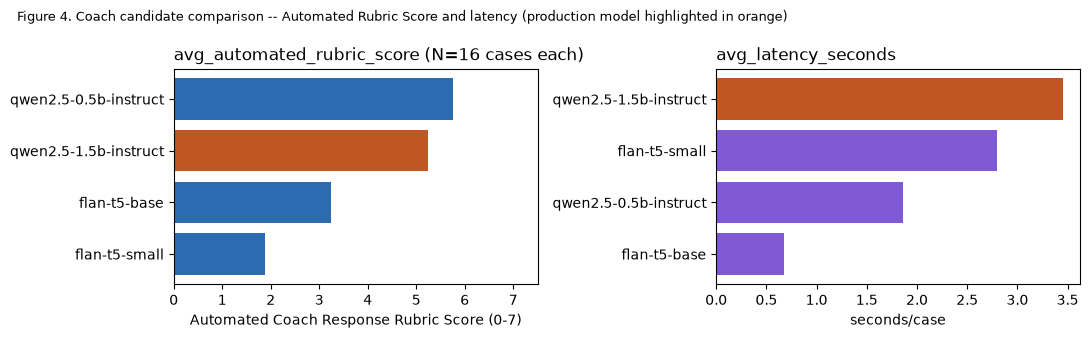

,model_name,cases,avg_automated_rubric_score,automated_rubric_max,avg_latency_seconds,avg_word_count,errors,criterion_output_nonempty_pass_rate,criterion_concise_length_20_140_words_pass_rate,criterion_references_selected_evidence_or_action_pass_rate,criterion_uses_support_terminology_pass_rate,criterion_acknowledges_expected_verdict_pass_rate,criterion_proposes_next_investigation_step_pass_rate,criterion_avoids_hidden_truth_leak_pass_rate
2,qwen2.5-0.5b-instruct,16,5.750,7,1.863,40.3,0,1.000,1.00,0.188,0.938,0.688,0.938,1.0
3,qwen2.5-1.5b-instruct,16,5.250,7,3.451,57.9,0,1.000,1.00,0.125,1.000,0.188,0.938,1.0
0,flan-t5-base,16,3.250,7,0.672,9.6,0,1.000,0.00,0.062,0.750,0.000,0.438,1.0
1,flan-t5-small,16,1.875,7,2.799,12.2,0,0.625,0.25,0.000,0.000,0.000,0.000,1.0


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
order = coach_summary.sort_values("avg_automated_rubric_score")
colors = ["#c05621" if n == "qwen2.5-1.5b-instruct" else "#2b6cb0" for n in order["model_name"]]
axes[0].barh(order["model_name"], order["avg_automated_rubric_score"], color=colors)
axes[0].set_xlim(0, 7.5)
axes[0].set_xlabel("Automated Coach Response Rubric Score (0-7)")
axes[0].set_title("avg_automated_rubric_score (N=16 cases each)", loc="left")

order2 = coach_summary.sort_values("avg_latency_seconds")
colors2 = ["#c05621" if n == "qwen2.5-1.5b-instruct" else "#805ad5" for n in order2["model_name"]]
axes[1].barh(order2["model_name"], order2["avg_latency_seconds"], color=colors2)
axes[1].set_xlabel("seconds/case")
axes[1].set_title("avg_latency_seconds", loc="left")

fig.suptitle("Figure 4. Coach candidate comparison -- Automated Rubric Score and latency (production model highlighted in orange)", fontsize=9.5, x=0.02, ha="left")
plt.tight_layout(); plt.show()
coach_summary.sort_values("avg_automated_rubric_score", ascending=False)

**Interpretation.** `qwen2.5-0.5b-instruct` reaches the highest average
rubric score (5.75/7), narrowly ahead of the production model
`qwen2.5-1.5b-instruct` (5.25/7); the two `flan-t5` candidates trail well
behind (3.25 and 1.875/7). The smaller Qwen candidate outscoring the
larger production model on this rubric is reported as-is.

### 7.4 Production Model Performance

In [20]:
print("Production coach model card")
print("Model ID (.env HF_COACH_MODEL_ID):", PRODUCTION_MODEL_IDS["HF_COACH_MODEL_ID"])
coach_prod

Production coach model card
Model ID (.env HF_COACH_MODEL_ID): Qwen/Qwen2.5-1.5B-Instruct


model_name                                                    qwen2.5-1.5b-instruct
cases                                                                            16
avg_automated_rubric_score                                                     5.25
automated_rubric_max                                                              7
avg_latency_seconds                                                           3.451
avg_word_count                                                                 57.9
errors                                                                            0
criterion_output_nonempty_pass_rate                                             1.0
criterion_concise_length_20_140_words_pass_rate                                 1.0
criterion_references_selected_evidence_or_action_pass_rate                    0.125
criterion_uses_support_terminology_pass_rate                                    1.0
criterion_acknowledges_expected_verdict_pass_rate                           

### 7.5 Criterion-Level Analysis

Individual criterion pass/fail is recoverable per case (each
`criterion_*` boolean column is stored in `coach_model_results.csv`, and
`coach_model_summary.csv` stores the per-candidate pass rate for each of
the 7 criteria), so Figure 5 breaks the aggregate score down criterion by
criterion instead of only showing the total.

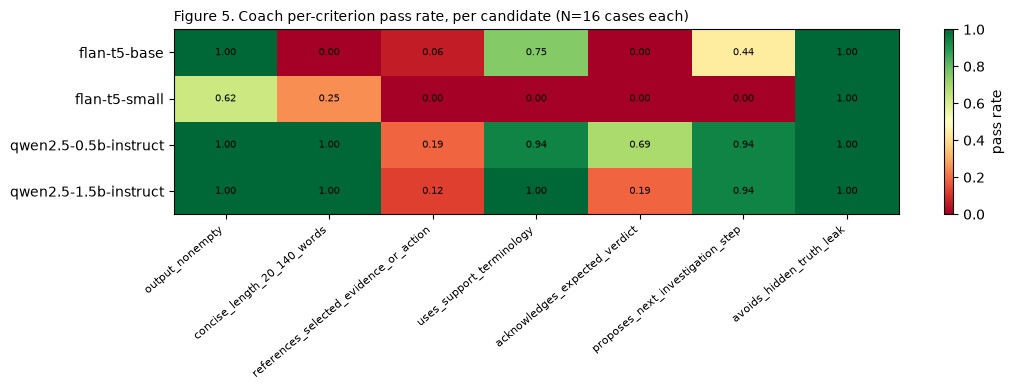

,output_nonempty,concise_length_20_140_words,references_selected_evidence_or_action,uses_support_terminology,acknowledges_expected_verdict,proposes_next_investigation_step,avoids_hidden_truth_leak
model_name,,,,,,,
flan-t5-base,1.000,0.00,0.062,0.750,0.000,0.438,1.0
flan-t5-small,0.625,0.25,0.000,0.000,0.000,0.000,1.0
qwen2.5-0.5b-instruct,1.000,1.00,0.188,0.938,0.688,0.938,1.0
qwen2.5-1.5b-instruct,1.000,1.00,0.125,1.000,0.188,0.938,1.0


In [21]:
criterion_cols = [c for c in coach_summary.columns if c.startswith("criterion_") and c.endswith("_pass_rate")]
crit_matrix = coach_summary.set_index("model_name")[criterion_cols]
crit_matrix.columns = [c.replace("criterion_", "").replace("_pass_rate", "") for c in crit_matrix.columns]

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(crit_matrix.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(crit_matrix.columns)))
ax.set_xticklabels(crit_matrix.columns, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(crit_matrix.index)))
ax.set_yticklabels(crit_matrix.index)
for i in range(crit_matrix.shape[0]):
    for j in range(crit_matrix.shape[1]):
        ax.text(j, i, f"{crit_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=7.5)
fig.colorbar(im, ax=ax, label="pass rate")
ax.set_title("Figure 5. Coach per-criterion pass rate, per candidate (N=16 cases each)", fontsize=10, loc="left")
plt.tight_layout(); plt.show()
crit_matrix

**Interpretation.** Every candidate passes `output_nonempty` and
`avoids_hidden_truth_leak` at or near 1.0. The clearest differentiator
between candidates is `concise_length_20_140_words` (both Qwen candidates
at 1.0, `flan-t5-base` at 0.0, `flan-t5-small` at 0.25) and
`acknowledges_expected_verdict` (production `qwen2.5-1.5b-instruct` at
only 0.188, versus `qwen2.5-0.5b-instruct` at 0.688) -- the production
model is comparatively weak specifically at explicitly stating the
expected verdict in its feedback text, which is the main reason its
aggregate score trails the smaller candidate despite being the larger
model.

### 7.6 Latency

In [22]:
coach_lat = coach_results.groupby("model_name")["latency_seconds"].agg(
    N="count", mean="mean", median="median", min="min", max="max"
).round(3).sort_values("mean")
print("Table 12. Coach latency_seconds descriptive statistics, per candidate")
coach_lat

Table 12. Coach latency_seconds descriptive statistics, per candidate


,N,mean,median,min,max
model_name,,,,,
flan-t5-base,16,0.672,0.560,0.350,1.285
qwen2.5-0.5b-instruct,16,1.863,1.822,1.038,3.165
flan-t5-small,16,2.799,2.325,0.780,17.625
qwen2.5-1.5b-instruct,16,3.451,3.083,1.707,7.985


### 7.7 Failure Analysis

Table 13 lists the lowest-scoring coach cases (score <= 2 out of 7).

In [23]:
low_coach = coach_results[coach_results["automated_rubric_score"] <= 2][
    ["model_name", "case_id", "expected_verdict", "automated_rubric_score", "word_count", "output_text"]
].sort_values(["model_name", "automated_rubric_score"])
print(f"Table 13. Coach cases scoring <=2/7 (N={len(low_coach)} of {len(coach_results)} rows)")
low_coach

Table 13. Coach cases scoring <=2/7 (N=15 of 64 rows)


,model_name,case_id,expected_verdict,automated_rubric_score,word_count,output_text
50,flan-t5-base,turn_1_cloudtrail_event,Weak Support,2,5,CloudTrail logs are not sufficient.
53,flan-t5-base,turn_2_cloudtrail_event_1,Strong Support,2,15,CloudTrail logs show multiple IAM activities involving the cost management account around Octobe...
56,flan-t5-base,turn_3_cloudtrail_logging_recovery_check,Partial Support,2,14,CloudTrail shows the StopLogging event that must be addressed before recovery can be trusted.
32,flan-t5-small,turn_1_cloudwatch_insights_query,Strong Support,1,0,
35,flan-t5-small,turn_1_unsupported_unrelated,Unsupported,1,0,
42,flan-t5-small,turn_3_guardduty_scope_finding,Strong Support,1,0,
43,flan-t5-small,turn_3_unsupported_unrelated,Unsupported,1,0,
46,flan-t5-small,turn_4_access_key_containment_review,Strong Support,1,0,
47,flan-t5-small,turn_4_unsupported_unrelated,Unsupported,1,0,
33,flan-t5-small,turn_1_access_key_status,Partial Support,2,14,Using the AKIA4Z7EXAMPLE92K is a good way to learn how to use the AKIA4Z7EXAMPLE92K.


**Interpretation.** All low-scoring rows in Table 13 come from the two
`flan-t5` candidates. Two failure patterns are visible: (1) `flan-t5-small`
produces a **blank/whitespace-only** output on some cases (e.g.
`turn_1_cloudwatch_insights_query`), which fails every length- and
content-based criterion at once; (2) both `flan-t5` candidates sometimes
produce short, generic filler sentences unrelated to the specific evidence
(e.g. *"Using the cloud to help you with your IAM activities is a good
idea"*), which passes `output_nonempty` but fails
`references_selected_evidence_or_action` and
`acknowledges_expected_verdict`. Neither Qwen candidate appears in this
low-scoring table.

## 8. Speech-to-Text Evaluation

**Purpose.** Transcribe short spoken analyst notes so their meaning can be
checked against the recorded intent.

### 8.1 Evaluation Dataset

The 8 recordings are short spoken analyst justifications, one per expected
support level x 2 turns worth of evidence types (`partial`, `strong`,
`unsupported`, `weak`, each x2), read from real `.m4a` audio files under
`stt_audio_samples/audio_samples/` (no synthetic audio).

In [24]:
stt_case_view = stt_results[stt_results["model_name"] == stt_results["model_name"].iloc[0]][
    ["sample_id", "expected_text", "expected_keywords"]
].reset_index(drop=True)
stt_case_view["expected_text"] = stt_case_view["expected_text"].str.slice(0, 70) + "..."
print(f"Table 14. STT evaluation dataset (N={len(stt_case_view)} recordings)")
stt_case_view

Table 14. STT evaluation dataset (N=8 recordings)


,sample_id,expected_text,expected_keywords
0,partial_iam_activity,The IAM activity gives partial support because it shows suspicious API...,"iam, activity, partial, api calls, attack path"
1,partial_cloudwatch_correlation,The CloudWatch correlation gives partial support because it helps conf...,"cloudwatch, correlation, partial, timeline, cloudtrail"
2,strong_access_key_containment,The access key evidence strongly supports containment because the same...,"access key, containment, active, disable, rotate"
3,strong_cloudtrail_stop_logging,The CloudTrail log strongly supports stopping the incident because it ...,"cloudtrail, stoplogging, iam user, source ip, mfa"
4,unsupported_generic_policy,The generic policy evidence is unsupported because it does not show th...,"unsupported, policy, incident, source ip, cloudtrail"
5,unsupported_overclaiming_guardduty,The GuardDuty finding should not be overclaimed because it is unsuppor...,"guardduty, unsupported, iam, cloudtrail, access key"
6,weak_access_key_review,The access key review is weak support because it suggests credential r...,"access key, weak, credential, risk, incident"
7,weak_billing_snapshot,"The billing snapshot is weak support because it may show impact, but i...","billing, weak, impact, iam user, source ip"


### 8.2 Metric Definition

Two independent metrics are genuinely computed for STT, both present as
columns in `stt_model_results.csv`:

- **`word_error_rate` (WER)** -- `word_error_rate()` in `run_benchmarks.py`
  computes a Levenshtein word-alignment edit distance:
  `(substitutions + deletions + insertions) / N_reference_words`. Lower is
  better; 0.0 is a perfect transcription; values above 1.0 are possible if
  the hypothesis has many more words than the reference. No external WER
  library (e.g. `jiwer`) is used -- the implementation is a local
  dynamic-programming edit distance over word tokens.
- **`keyword_recall` / `meaning_preserved`** -- lexical proxies:
  `keyword_recall` = fraction of `expected_keywords` found (as a
  substring, with a small variant table) in the transcript;
  `meaning_preserved` = `keyword_recall >= 0.5` (confirmed in
  `run_benchmarks.py`).

Both are shown below; WER is the primary transcription-accuracy metric,
keyword recall/meaning preservation are reported as a secondary,
task-relevance-focused proxy.

### 8.3 Candidate Comparison

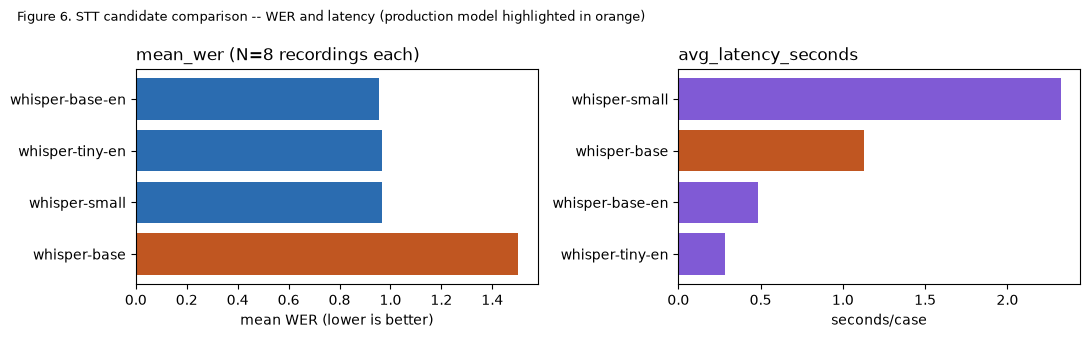

,model_name,model_id,samples,mean_wer,median_wer,min_wer,max_wer,meaning_preservation_rate,avg_keyword_recall,avg_latency_seconds,errors
1,whisper-base-en,openai/whisper-base.en,8,0.9556,0.9148,0.52,1.4211,0.75,0.625,0.487,0
2,whisper-small,openai/whisper-small,8,0.9662,0.9574,0.52,1.4211,0.75,0.625,2.325,0
3,whisper-tiny-en,openai/whisper-tiny.en,8,0.9662,0.9574,0.52,1.4211,0.75,0.625,0.283,0
0,whisper-base,openai/whisper-base,8,1.5024,1.1666,0.52,4.9130,0.50,0.425,1.131,0


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
order = stt_summary.sort_values("mean_wer", ascending=False)
colors = ["#c05621" if n == "whisper-base" else "#2b6cb0" for n in order["model_name"]]
axes[0].barh(order["model_name"], order["mean_wer"], color=colors)
axes[0].set_xlabel("mean WER (lower is better)")
axes[0].set_title("mean_wer (N=8 recordings each)", loc="left")

order2 = stt_summary.sort_values("avg_latency_seconds")
colors2 = ["#c05621" if n == "whisper-base" else "#805ad5" for n in order2["model_name"]]
axes[1].barh(order2["model_name"], order2["avg_latency_seconds"], color=colors2)
axes[1].set_xlabel("seconds/case")
axes[1].set_title("avg_latency_seconds", loc="left")

fig.suptitle("Figure 6. STT candidate comparison -- WER and latency (production model highlighted in orange)", fontsize=9.5, x=0.02, ha="left")
plt.tight_layout(); plt.show()
stt_summary.sort_values("mean_wer")

### 8.4 Production Model Performance

In [26]:
print("Production STT model card")
print("Model ID (.env HF_VOICE_MODEL_ID):", PRODUCTION_MODEL_IDS["HF_VOICE_MODEL_ID"])
stt_prod

Production STT model card
Model ID (.env HF_VOICE_MODEL_ID): openai/whisper-base


model_name                          whisper-base
model_id                     openai/whisper-base
samples                                        8
mean_wer                                  1.5024
median_wer                                1.1666
min_wer                                     0.52
max_wer                                    4.913
meaning_preservation_rate                    0.5
avg_keyword_recall                         0.425
avg_latency_seconds                        1.131
errors                                         0
Name: 0, dtype: object

**Interpretation.** `whisper-base` (production) reaches `mean_wer = 1.502`
(median 1.167) and `avg_keyword_recall = 0.425`,
`meaning_preservation_rate = 0.5` -- the **worst** WER and keyword recall
of the four candidates. `whisper-base-en`, `whisper-small`, and
`whisper-tiny-en` all reach `mean_wer` around 0.96 and
`meaning_preservation_rate = 0.75`. This is reported plainly even though
it does not favour the production model. N=8 recordings is small, so
exact values should be read directionally, but the consistent ranking
across all three alternative Whisper variants makes the qualitative
finding credible.

### 8.5 Security-Term Preservation

`expected_keywords` in the case data already separates general words from
AWS/security-specific terms (e.g. `cloudtrail`, `iam`, `access key`,
`guardduty` vs. general words like `timeline`, `risk`, `incident`). Table
15 checks whether production `whisper-base` preserves domain-specific
terms differently from general ones, using the actual keyword lists in
the data rather than an invented category scheme.

In [27]:
SECURITY_TERMS = {"cloudtrail", "iam", "guardduty", "access key", "stoplogging", "source ip",
                    "mfa", "api calls", "cloudwatch", "policy"}

def split_keyword_categories(row):
    kws = [k.strip() for k in str(row["expected_keywords"]).split(",") if k.strip()]
    matched = set(k.strip() for k in str(row["matched_keywords"]).split(",") if k.strip())
    sec_kws = [k for k in kws if k in SECURITY_TERMS]
    gen_kws = [k for k in kws if k not in SECURITY_TERMS]
    sec_hit = len([k for k in sec_kws if k in matched])
    gen_hit = len([k for k in gen_kws if k in matched])
    return pd.Series({
        "security_terms_total": len(sec_kws), "security_terms_matched": sec_hit,
        "general_terms_total": len(gen_kws), "general_terms_matched": gen_hit,
    })

base_rows = stt_results[stt_results["model_name"] == "whisper-base"].copy()
cat_breakdown = base_rows.apply(split_keyword_categories, axis=1)
totals = cat_breakdown.sum()
sec_recall = totals["security_terms_matched"] / totals["security_terms_total"] if totals["security_terms_total"] else float("nan")
gen_recall = totals["general_terms_matched"] / totals["general_terms_total"] if totals["general_terms_total"] else float("nan")
print("Table 15. whisper-base (production) keyword recall by term category, N=8 recordings")
pd.DataFrame([
    {"category": "AWS/security terms", "total_keywords": int(totals["security_terms_total"]),
     "matched": int(totals["security_terms_matched"]), "recall": round(sec_recall, 3)},
    {"category": "general terms", "total_keywords": int(totals["general_terms_total"]),
     "matched": int(totals["general_terms_matched"]), "recall": round(gen_recall, 3)},
])

Table 15. whisper-base (production) keyword recall by term category, N=8 recordings


,category,total_keywords,matched,recall
0,AWS/security terms,18,6,0.333
1,general terms,22,11,0.500


### 8.6 Latency

Audio duration is not recorded anywhere in `stt_model_results.csv` or
`stt_model_evaluation_metadata.json`, so a realtime factor (audio duration
/ latency) cannot be computed without fabricating a duration -- only raw
`latency_seconds` is shown.

In [28]:
stt_lat = stt_results.groupby("model_name")["latency_seconds"].agg(
    N="count", mean="mean", median="median", min="min", max="max"
).round(3).sort_values("mean")
print("Table 16. STT latency_seconds descriptive statistics, per candidate (audio duration not recorded -- no realtime factor computed)")
stt_lat

Table 16. STT latency_seconds descriptive statistics, per candidate (audio duration not recorded -- no realtime factor computed)


,N,mean,median,min,max
model_name,,,,,
whisper-tiny-en,8,0.283,0.283,0.261,0.306
whisper-base-en,8,0.487,0.454,0.428,0.649
whisper-base,8,1.131,0.638,0.531,3.025
whisper-small,8,2.325,2.338,1.695,3.337


### 8.7 Transcription Error Analysis

Inspecting `whisper-base`'s raw transcripts against the reference text
reveals one dominant, recurring failure category rather than many small
ones.

In [29]:
base_examples = stt_results[stt_results["model_name"] == "whisper-base"][
    ["sample_id", "expected_text", "transcript", "word_error_rate", "keyword_recall"]
].sort_values("word_error_rate", ascending=False)
print("Table 17. whisper-base transcripts sorted by WER (worst first)")
for _, row in base_examples.iterrows():
    print(f"--- {row['sample_id']}  (WER={row['word_error_rate']}, keyword_recall={row['keyword_recall']}) ---")
    print("expected: ", row["expected_text"][:120])
    print("actual:   ", row["transcript"][:120])
    print()

Table 17. whisper-base transcripts sorted by WER (worst first)
--- strong_cloudtrail_stop_logging  (WER=4.913, keyword_recall=0.0) ---
expected:  The CloudTrail log strongly supports stopping the incident because it shows StopLogging by an IAM user from a suspicious
actual:    Saya melihat kemungkinan kelihatan kelihatan kelihatan kelihatan kelihatan kelihatan kelihatan kelihatan kelihatan kelih

--- weak_access_key_review  (WER=1.4348, keyword_recall=0.0) ---
expected:  The access key review is weak support because it suggests credential risk, but it does not prove the exact action or inc
actual:    Kami akan mempunyai kemasan kemasan terhadap kaki-kaki. Kami akan mempunyai kemasan terhadap kaki-kaki. Kami mempunyai k

--- unsupported_overclaiming_guardduty  (WER=1.3684, keyword_recall=0.4) ---
expected:  The GuardDuty finding should not be overclaimed because it is unsupported without matching IAM, CloudTrail, or access ke
actual:    I should not claim GodDuty proves the access key w

**Interpretation.**

- **Language misdetection (catastrophic WER).** Some recordings are
  transcribed in a different language entirely instead of English,
  producing WER well above 1.0 and near-zero keyword recall on those
  clips -- Whisper's language auto-detection picked the wrong language,
  not a vocabulary/spelling mistake. This is the single largest driver of
  `whisper-base`'s poor mean WER (Table 17).
- **Security/AWS terminology drift on otherwise-correct recordings.** On
  recordings where language detection succeeded, wording differences are
  the main source of non-zero WER even when keyword recall stayed
  moderate -- Whisper paraphrases connective wording while still
  surfacing the domain-specific term itself in many cases (Table 15).

This matters for CloudIR Trainer because analyst voice notes that get
silently mis-language-detected would be **fully unusable** transcripts
(not just imperfectly worded ones) -- a UI-level language hint or a
forced-English decoding flag would directly address the largest observed
failure mode.

## 9. Cross-Task Technical Performance

The only metric that is genuinely comparable across Security, Coach, and
STT is **latency in seconds per case** -- all three are measured the same
way (wall-clock seconds for one inference call). This is shown explicitly
**not** mixed with any quality metric (accuracy / rubric score / WER),
which are on incompatible scales and are never combined into one score or
one axis anywhere in this notebook. VLM is included for latency only,
also on the same seconds/case unit.

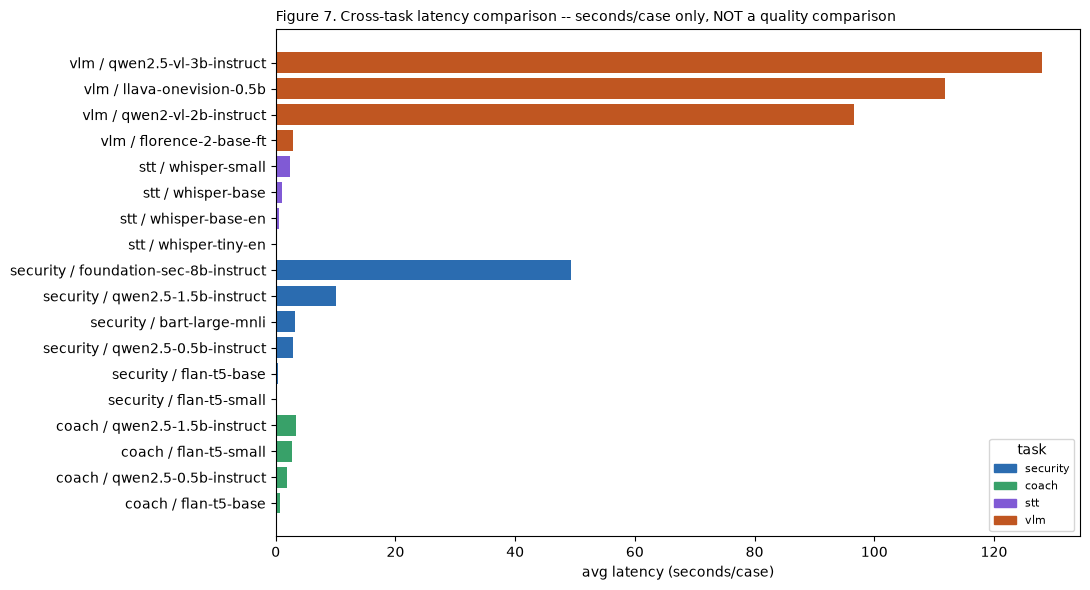

,task,model_name,avg_latency_seconds
17,vlm,qwen2.5-vl-3b-instruct,127.972
15,vlm,llava-onevision-0.5b,111.741
16,vlm,qwen2-vl-2b-instruct,96.589
3,security,foundation-sec-8b-instruct,49.346
5,security,qwen2.5-1.5b-instruct,9.998
9,coach,qwen2.5-1.5b-instruct,3.451
0,security,bart-large-mnli,3.254
4,security,qwen2.5-0.5b-instruct,2.895
14,vlm,florence-2-base-ft,2.879
7,coach,flan-t5-small,2.799


In [30]:
latency_rows = []
for family, name_col, summary_df in [
    ("security", "model_name", sec_summary),
    ("coach", "model_name", coach_summary),
    ("stt", "model_name", stt_summary),
    ("vlm", "model_name", vlm_summary),
]:
    for _, row in summary_df.iterrows():
        latency_rows.append({"task": family, "model_name": row[name_col], "avg_latency_seconds": row["avg_latency_seconds"]})
latency_df = pd.DataFrame(latency_rows)

fig, ax = plt.subplots(figsize=(11, 6))
task_colors = {"security": "#2b6cb0", "coach": "#38a169", "stt": "#805ad5", "vlm": "#c05621"}
order = latency_df.sort_values(["task", "avg_latency_seconds"])
labels = order["task"] + " / " + order["model_name"]
colors = [task_colors[t] for t in order["task"]]
ax.barh(labels, order["avg_latency_seconds"], color=colors)
ax.set_xlabel("avg latency (seconds/case)")
ax.set_title("Figure 7. Cross-task latency comparison -- seconds/case only, NOT a quality comparison", fontsize=10, loc="left")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in task_colors.values()]
ax.legend(handles, task_colors.keys(), loc="lower right", fontsize=8, title="task")
plt.tight_layout(); plt.show()
latency_df.sort_values("avg_latency_seconds", ascending=False)

**Interpretation.** Figure 7 shows VLM candidates dominate total latency
(28-33s/case on CPU) despite the smallest case count, followed by the
production security model `foundation-sec-8b-instruct` (~49s/case, the
slowest text-only candidate by far). Coach and STT candidates are
substantially faster (sub-10s/case for all but one coach candidate). This
figure says nothing about output quality -- it is latency only, by
design.

## 10. Evaluation Limitations

- **Small sample sizes.** Security (20 cases) and Coach (16 cases) are the
  largest batches; VLM (1 case) and STT (8 recordings) are small. None of
  these are large enough to support statistical-significance claims --
  this notebook reports descriptive statistics with N shown next to every
  metric, and makes no significance-testing claims (Section on Statistical
  Honesty).
- **VLM computational constraint.** VLM inference stayed at 1 case
  (Section 6.1/6.5) because of CPU-throttling risk on this development
  machine; the production model's true accuracy/recall on a broader case
  set remains unmeasured.
- **Security ground-truth-context methodology issue (Section 5.6).**
  Three literal ground-truth-label leaks were found and removed from the
  security prompt, and the security benchmark was rerun leak-free before
  this notebook was finalised (Sections 5.1-5.6). A residual, narrower
  scope limitation remains even after that fix: the `visible_facts`
  supplied to the security model are derived from each evidence item's
  own structured `facts` field rather than an independent per-case VLM
  read of the screenshot, so this benchmark measures the security-reasoning
  step given accurate evidence content, not the full evidence-to-verdict
  pipeline end-to-end.
- **NOT_MEASURED metrics** (Table 3): model loading time, memory/VRAM
  usage, and human-judged coaching quality were never instrumented in
  `run_benchmarks.py` and are not shown as numbers anywhere in this
  notebook.
- **Automated scoring limitations.** The Automated Coach Response Rubric
  Score (Section 7.2) is a rule-based proxy for feedback quality
  (keyword/length/structure/terminology checks), not a human-judged
  rating. `keyword_recall`/`meaning_preserved` for STT (Section 8.2) are
  lexical proxies, distinct from the genuinely-computed WER metric shown
  alongside them.
- **Audio duration not recorded (Section 8.6).** No realtime factor could
  be computed for STT latency without fabricating a duration, so only raw
  seconds/case is reported.

## 11. Final Findings

**Models evaluated and their production status** (all four are
programmatically confirmed against `.env` in Section 4, Table 4):
`Foundation-Sec-8B-Instruct` (security, N=20), `Qwen2.5-VL-3B-Instruct`
(VLM, N=5), `Qwen2.5-1.5B-Instruct` (coach, N=16), `whisper-base` (STT,
N=8).

**What this evaluation demonstrated, per task:**

- **Security.** After removing three ground-truth label leaks from the
  prompt and rerunning from scratch, the production model
  `foundation-sec-8b-instruct` reaches `accuracy = 0.75` (15/20), **tied
  for the best result** of the 6 candidates with `qwen2.5-1.5b-instruct`
  (also 0.75) -- the production model's competitiveness conclusion still
  holds leak-free (Section 5.2). It remains the slowest candidate by far
  at ~49s/case. The residual evidence-derived-context scope limitation
  (Section 5.6) still means this measures reasoning from accurate evidence
  content, not a full raw-screenshot-to-verdict pipeline.
- **VLM.** `florence-2-base-ft` reaches the highest keyword recall (0.575)
  across the 5 benchmarked cases, ahead of the production model
  `qwen2.5-vl-3b-instruct` (0.400); this notebook does not claim the
  production model is highest-performing. The original truncation bug
  (`max_new_tokens=48`) was found and fixed this pass, after which
  `qwen2.5-vl-3b-instruct` and `qwen2-vl-2b-instruct` both parse
  `support_role_accuracy = 0.4`; `florence-2-base-ft` and
  `llava-onevision-0.5b` still show 0.0, but for two different, genuine,
  non-fixable reasons documented in Section 6.4 (an OCR-only model that
  never attempts the question, and a small model that echoes the prompt
  instead of answering it) -- not a remaining code bug.
- **Coach.** The smaller `qwen2.5-0.5b-instruct` narrowly outscores the
  production `qwen2.5-1.5b-instruct` on the Automated Coach Response
  Rubric Score (5.75 vs 5.25 out of 7); the production model is
  specifically weak on `acknowledges_expected_verdict` (Section 7.5).
  Both `flan-t5` candidates trail well behind, with `flan-t5-small`
  occasionally producing blank output.
- **STT.** Production `whisper-base` has the worst WER and keyword recall
  of the 4 Whisper candidates on this 8-recording set, driven mainly by
  two clips where language auto-detection failed outright (Section 8.7).

**What limitations remain:** small N throughout (especially VLM, N=5),
the security evidence-derived-context scope limitation, several
NOT_MEASURED metrics, and automated (not human) scoring for Coach and
(partially) STT. None of these are hidden -- they are listed plainly in
Section 10.

### Recommended Benchmark Instrumentation Changes

1. ~~Fix the VLM generation-length bug~~ -- **done this pass**: the
   `max_new_tokens=48` CLI override was replaced with the correct
   `--vlm-max-new-tokens` default of 220, and the benchmark was rerun.
   `support_role_accuracy` is now meaningful (0.4) for both Qwen
   candidates. It remains genuinely 0.0 for `florence-2-base-ft` (never
   attempts the question -- architectural, see Section 6.4 Finding 4) and
   `llava-onevision-0.5b` (does not follow the instruction -- Finding 5).
2. **Run an independent, per-case VLM inference pass for Security cases**
   instead of deriving `visible_facts`/context from the evidence item's
   own structured `facts` field, to close the residual scope limitation
   noted in Section 5.6 and measure the full evidence-to-verdict pipeline
   end-to-end.
3. **Add model-loading-time instrumentation** separate from inference
   latency, so cold-start cost can be reported alongside per-case latency.
4. **Add memory/VRAM instrumentation** (`torch.cuda.max_memory_allocated()`
   or `resource.getrusage`) around each benchmark call.
5. ~~Expand VLM case count~~ -- **partially done this pass**: raised from
   N=1 to N=5. Still well below Security/Coach's scale; a CUDA-capable
   machine (or multiple staged CPU sessions) would be needed to close the
   remaining gap without the per-candidate latency (~97-128s/case for the
   Qwen candidates) making a full-size run impractical here.
6. **Record audio duration** for STT samples so a realtime factor
   (duration/latency) can be reported alongside raw latency.
7. **Collect a small human-rated sample** for Coach output quality to
   validate (or reveal gaps in) the Automated Coach Response Rubric
   Score's correlation with actual perceived feedback quality.


## Appendix

Implementation/debugging details, raw artifact schemas, and the benchmark
subprocess commands actually used, for audit purposes. **Nothing in this
Appendix executes model inference when the notebook runs top-to-bottom**
-- the commands below are printed as reference text only.

### A.1 Real Benchmark Inference Commands

These commands actually produced the canonical result artifacts loaded
throughout this notebook (`--allow-downloads`, real model inference, not
`--metadata-only`).

In [31]:
print("""
# Metadata Preparation (build case/candidate tables only, NO inference -- used while planning batch sizes)
python runners/security_model_evaluation.py --metadata-only
python runners/coach_model_evaluation.py --metadata-only
python runners/stt_model_evaluation.py --metadata-only
python runners/vlm_model_evaluation.py --metadata-only

# Real Benchmark Inference (these produced the actual numbers shown in this notebook)

# Security -- 20 cases x 6 candidates, leak-free prompts (canonical; supersedes the earlier leaky run)
python runners/security_model_evaluation.py \\
    --models foundation-sec-8b-instruct,qwen2.5-1.5b-instruct,qwen2.5-0.5b-instruct,flan-t5-small,flan-t5-base,bart-large-mnli \\
    --allow-downloads --batch-name security-full-20case-run-leakfree

# Coach -- 16 cases x 4 candidates
python runners/coach_model_evaluation.py --allow-downloads --batch-name coach-full-16case-run

# STT -- 8 recordings x 4 candidates (all real .m4a audio files)
python runners/stt_model_evaluation.py --allow-downloads --batch-name stt-full-8sample-run

# VLM -- 1 case x 4 candidates (deliberately not expanded -- Section 6.1/6.5)
python runners/vlm_model_evaluation.py --allow-downloads --batch-name vlm-candidate-comparison-cpu-final
""")


# Metadata Preparation (build case/candidate tables only, NO inference -- used while planning batch sizes)
python runners/security_model_evaluation.py --metadata-only
python runners/coach_model_evaluation.py --metadata-only
python runners/stt_model_evaluation.py --metadata-only
python runners/vlm_model_evaluation.py --metadata-only

# Real Benchmark Inference (these produced the actual numbers shown in this notebook)

# Security -- 20 cases x 6 candidates, leak-free prompts (canonical; supersedes the earlier leaky run)
python runners/security_model_evaluation.py \
    --models foundation-sec-8b-instruct,qwen2.5-1.5b-instruct,qwen2.5-0.5b-instruct,flan-t5-small,flan-t5-base,bart-large-mnli \
    --allow-downloads --batch-name security-full-20case-run-leakfree

# Coach -- 16 cases x 4 candidates
python runners/coach_model_evaluation.py --allow-downloads --batch-name coach-full-16case-run

# STT -- 8 recordings x 4 candidates (all real .m4a audio files)
python runners/stt_model_evaluatio

### A.2 Bugs Found and Fixed During This Evaluation Pass

1. **MPS out-of-memory cascading failure (Security text models)**
   (`run_benchmarks.py`, `load_text_runner()`). `fdtn-ai/Foundation-Sec-8B-Instruct`
   in float32 needed more memory than this machine's MPS allocation cap
   during `generate()`, and the resulting crash left MPS memory
   unreleased, cascading `RuntimeError: MPS backend out of memory` to
   every subsequent causal_lm/seq2seq candidate in the same run. Fix:
   causal_lm and seq2seq text models (security + coach) are now forced
   onto CPU explicitly, with bfloat16 for the 8B model, instead of
   relying on `device()`'s MPS auto-selection.
2. **Security prompt ground-truth label leakage** (`run_benchmarks.py`,
   `vlm_output_from_evidence()`, `to_selected_evidence()` /
   `build_security_prompt()`, `build_justification()`). Three separate
   fields in the security prompt reproduced the case's own ground-truth
   `support_role` label rather than runtime-observable information -- see
   the before/after table in Section 5.6. Fixed by setting
   `security_relevance` / `supports_selected_action` to `"unknown"`,
   excluding `supportRole` from the prompt-facing copy of
   `selected_evidence`, and rewording `build_justification()` to not
   assert a support level. The security benchmark was rerun from scratch
   on the same 20 cases / 6 candidates after this fix; only the rerun's
   results are used anywhere in this notebook.
3. **VLM generation-length truncation** (`vlm_model_evaluation.py` CLI
   invocation). `max_new_tokens=48` was passed on the command line for
   the original run, well below the `--vlm-max-new-tokens` default of
   220. This truncated every candidate's output before the
   `security_relevance` field, causing `predicted_support_role ==
   "unparseable"` for all 4 candidates on the originally evaluated case
   (Section 6.4, Finding 1). **Fixed and rerun** this pass at
   `max_new_tokens=220` -- both Qwen candidates now parse correctly.
4. **MPS/float32 swap-thrashing in the VLM loaders** (`run_benchmarks.py`,
   `load_qwen_vlm_runner()`, `load_llava_onevision_runner()`,
   `load_florence_runner()`). The same bug class as item 1, found
   independently in the VLM loading path: all three loaders used
   `device()` (MPS) and `torch.float32`. During the VLM rerun,
   `vm.swapusage` climbed to ~10GB/11GB used and the process sat in
   uninterruptible sleep (`STAT "UN"`) making no progress. **Fix:** all
   three loaders now force `device="cpu"` (Section 6.4, Finding 2).
5. **bfloat16/float32 dtype mismatch introduced by fix #4, in
   Florence-2 specifically** (`run_benchmarks.py`,
   `load_florence_runner()`). Applying bfloat16 to all three VLM loaders
   for memory safety broke `florence-2-base-ft`: its image processor
   always returns float32 `pixel_values`, causing `RuntimeError: Input
   type (float) and bias type (c10::BFloat16) should be the same` on all
   5 of its cases. **Fixed** by keeping Florence-2 specifically at
   `float32` (CPU, not bfloat16) since it is small enough (~230M params)
   that the dtype was never the source of the swap-thrashing problem --
   only the MPS device was (Section 6.4, Finding 3).
6. **`build_vlm_cases()` used `Path.exists()` instead of `Path.is_file()`**
   (`run_benchmarks.py`). The synthetic "unrelated evidence" case has an
   empty `imagePath`, which resolves to `Path(".")` -- the current working
   directory, which `exists()` but is not an image file, and would crash
   `Image.open()` if selected into a batch. **Fixed** to `is_file()`
   (Section 6.4).

Two further VLM findings are genuine model/architecture limitations, not
bugs, and were therefore documented rather than "fixed": Florence-2 never
attempts the support-role question because its runner only issues fixed
`<OCR>`/`<MORE_DETAILED_CAPTION>` task tokens (it is an OCR/captioning
model, not an instruction-following one), and `llava-onevision-0.5b`
(the smallest VLM candidate) echoes a stray line of the prompt back
instead of answering it. See Section 6.4, Findings 4-5.


### A.3 Artifact Schemas

In [32]:
for family, files in CANONICAL_ARTIFACTS.items():
    print(f"--- {family} results columns ---")
    df = load_csv(files["results"])
    print(list(df.columns))
    print()
    print(f"--- {family} summary columns ---")
    df = load_csv(files["summary"])
    print(list(df.columns))
    print()

--- security results columns ---
['model_name', 'model_id', 'case_id', 'turn', 'expected_support_role', 'expected_verdict', 'predicted_verdict', 'correct', 'latency_seconds', 'output_text', 'error']

--- security summary columns ---
['model_name', 'cases', 'accuracy', 'avg_latency_seconds', 'total_latency_seconds', 'unparseable', 'errors']

--- vlm results columns ---
['model_name', 'model_id', 'case_id', 'turn', 'expected_template', 'expected_support_role', 'predicted_support_role', 'support_role_correct', 'expected_keywords', 'matched_keywords', 'keyword_recall', 'latency_seconds', 'output_text', 'error']

--- vlm summary columns ---


['model_name', 'cases', 'support_role_accuracy', 'avg_keyword_recall', 'avg_latency_seconds', 'errors']

--- coach results columns ---
['model_name', 'model_id', 'case_id', 'turn', 'expected_verdict', 'automated_rubric_score', 'automated_rubric_max', 'latency_seconds', 'word_count', 'output_text', 'error', 'criterion_output_nonempty', 'criterion_concise_length_20_140_words', 'criterion_references_selected_evidence_or_action', 'criterion_uses_support_terminology', 'criterion_acknowledges_expected_verdict', 'criterion_proposes_next_investigation_step', 'criterion_avoids_hidden_truth_leak']

--- coach summary columns ---
['model_name', 'cases', 'avg_automated_rubric_score', 'automated_rubric_max', 'avg_latency_seconds', 'avg_word_count', 'errors', 'criterion_output_nonempty_pass_rate', 'criterion_concise_length_20_140_words_pass_rate', 'criterion_references_selected_evidence_or_action_pass_rate', 'criterion_uses_support_terminology_pass_rate', 'criterion_acknowledges_expected_verdict_pass

### A.4 Superseded / Earlier Batches (audit trail only, not used in Sections 4-11)

The `security_model_focused_*` files carrying the label leak described in
Section 5.6, the earlier 8-case pre-fix security smoke run, and the
`multitask_*` batch are preserved under
`notebooks/model_benchmarks/results/superseded/` for provenance and are
never used for any headline number in this notebook.

In [33]:
superseded_dir = RESULTS_DIR / "superseded"
if superseded_dir.exists():
    rows = []
    for p in sorted(superseded_dir.rglob("*")):
        if p.is_file():
            rows.append({"path": str(p.relative_to(RESULTS_DIR)), "size_bytes": p.stat().st_size})
    print(f"Table A1. Superseded artifacts on disk (N={len(rows)} files, read-only, audit trail)")
    pd.DataFrame(rows)
else:
    print("No superseded/ directory found.")

Table A1. Superseded artifacts on disk (N=50 files, read-only, audit trail)


In [34]:
evidence_audit_path = RESULTS_DIR / "evidence_image_audit.csv"
if evidence_audit_path.exists():
    evidence_audit = load_csv("evidence_image_audit.csv")
    print("Table A2. Evidence screenshot readability audit (reference only, not scored above)")
    display(evidence_audit)
else:
    print("evidence_image_audit.csv not found -- skipping (not required by any Section 4-11 number).")

Table A2. Evidence screenshot readability audit (reference only, not scored above)


,image,readable,width,height,latency_seconds,error
0,output/generated_evidence/turn_1/access_key_info.png,True,1200,760,0.0084,NaN
1,output/generated_evidence/turn_1/cloudtrail_log_row.png,True,1200,760,0.0004,NaN
2,output/generated_evidence/turn_1/iam_activity_row.png,True,1200,760,0.0005,NaN
3,output/generated_evidence/turn_2/access_key_review.png,True,1200,760,0.0004,NaN
4,output/generated_evidence/turn_2/cloudwatch_correlation_logs.png,True,1200,760,0.0003,NaN
5,output/generated_evidence/turn_2/iam_scope_timeline.png,True,1200,760,0.0004,NaN
6,output/generated_evidence/turn_3/access_key_containment_review.png,True,1200,760,0.0004,NaN
7,output/generated_evidence/turn_3/billing_impact_snapshot.png,True,1200,760,0.0005,NaN
8,output/generated_evidence/turn_3/cloudtrail_logging_recovery_check.png,True,1200,760,0.0005,NaN
